# Create data structure for loading initial data

In [1]:
import pandas as pd
import os

DATASETS_PATH = os.getenv("DATASETS_PATH")

class GroceryRetailSalesData:
    def __init__(self):
        self._df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")
        self._df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")
        self._df_sales_validation = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_validation.csv")
        self._df_sales_evaluation = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")
        self._store_ids = self._df_sales_validation['store_id'].unique()

initial_data = GroceryRetailSalesData()

# Create cumulative sales per day for each store 

In [2]:
def generate_cumulative_sales_time_series(initial_data: GroceryRetailSalesData):
    df = initial_data._df_sales_evaluation

    # Identify day columns
    day_cols = df.columns[df.columns.str.startswith('d_')].tolist()

    # Aggregate across items per store (vectorized)
    df_grouped = df.groupby('store_id')[day_cols].sum()

    # Convert wide → long format
    df_long = df_grouped.stack().reset_index()
    df_long.columns = ['store_id', 'd', 'y']

    # Merge with calendar
    df_long = df_long.merge(
        initial_data._df_calendar[['d', 'date']],
        on='d',
        how='left'
    )

    # Set MultiIndex
    df_long = df_long.set_index(['store_id', 'd'])
    
    df_long = df_long.reindex(columns=['date', 'y'])
    
    return df_long

cumulative_sales_time_series = generate_cumulative_sales_time_series(initial_data)

print(cumulative_sales_time_series)

                       date     y
store_id d                       
CA_1     d_1     2011-01-29  4337
         d_2     2011-01-30  4155
         d_3     2011-01-31  2816
         d_4     2011-02-01  3051
         d_5     2011-02-02  2630
...                     ...   ...
WI_3     d_1937  2016-05-18  3268
         d_1938  2016-05-19  3398
         d_1939  2016-05-20  4126
         d_1940  2016-05-21  4519
         d_1941  2016-05-22  4757

[19410 rows x 2 columns]


In [3]:
%timeit -n 2 cumulative_sales_time_series = generate_cumulative_sales_time_series(initial_data)

273 ms ± 7.26 ms per loop (mean ± std. dev. of 7 runs, 2 loops each)


# Fit Prophet models to the cumulative sales time series

In [4]:
from joblib import Parallel, delayed
from prophet import Prophet

def fit_single_store(store, df_store):
    df_loc = df_store.reset_index()[['date', 'y']].rename(columns={'date': 'ds'})
    model = Prophet(interval_width=0.95)
    model.fit(df_loc)
    return store, model

def fit_prophet_models(df_long, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_single_store)(store, df_store)
        for store, df_store in df_long.groupby(level=0)
    )
    
    return dict(results)

prophet_models = fit_prophet_models(cumulative_sales_time_series)

print(prophet_models)

{'CA_1': <prophet.forecaster.Prophet object at 0x0000025FB07C46E0>, 'CA_2': <prophet.forecaster.Prophet object at 0x0000025F836DBCB0>, 'CA_3': <prophet.forecaster.Prophet object at 0x0000025F8F740830>, 'CA_4': <prophet.forecaster.Prophet object at 0x0000025FB07C4AD0>, 'TX_1': <prophet.forecaster.Prophet object at 0x0000025F8F740980>, 'TX_2': <prophet.forecaster.Prophet object at 0x0000025F836DBE00>, 'TX_3': <prophet.forecaster.Prophet object at 0x0000025FB07C4440>, 'WI_1': <prophet.forecaster.Prophet object at 0x0000025FB07C4590>, 'WI_2': <prophet.forecaster.Prophet object at 0x0000025F836DBB60>, 'WI_3': <prophet.forecaster.Prophet object at 0x0000025FB07C4830>}


In [5]:
%timeit prophet_models = fit_prophet_models(cumulative_sales_time_series)

1.52 s ± 194 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Make Prophet forecast for each store

In [6]:
import pandas as pd

def forecast_single(store_id, model, future_days):
    # Generate future dataframe and predict
    future = model.make_future_dataframe(periods=future_days)
    forecast = model.predict(future)

    # Keep only relevant columns and add store_id
    df = forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']].copy()
    df['store_id'] = store_id
    return df

def generate_prophet_forecasts_parallel(prophet_models, future_days=28, n_jobs=-1):
    # Parallel prediction
    results = Parallel(n_jobs=n_jobs)(
        delayed(forecast_single)(store_id, model, future_days)
        for store_id, model in prophet_models.items()
    )

    # Concatenate all results into one DataFrame
    df = pd.concat(results, ignore_index=True)

    # Set MultiIndex for clean alignment
    df = df.set_index(['store_id', 'ds']).sort_index()

    return df

df_cumulative_sales_forecasts = generate_prophet_forecasts_parallel(prophet_models, future_days=28)
print(df_cumulative_sales_forecasts)

                      yhat_lower   yhat_upper         yhat
store_id ds                                               
CA_1     2011-01-29  2908.439131  4807.390199  3892.324917
         2011-01-30  3111.865514  4841.135438  3967.291367
         2011-01-31  1786.202104  3569.045216  2698.496523
         2011-02-01  1281.663686  3150.169829  2261.957543
         2011-02-02  1230.548691  3011.844414  2178.750192
...                          ...          ...          ...
WI_3     2016-06-15  2444.360065  4685.130040  3533.552423
         2016-06-16  2528.308915  4690.684336  3592.544156
         2016-06-17  3070.689731  5245.637027  4142.672176
         2016-06-18  3735.225541  5875.695480  4784.121712
         2016-06-19  3410.264148  5553.519989  4538.212658

[19690 rows x 3 columns]


In [7]:
timeit -n 2 df_cumulative_sales_forecasts = generate_prophet_forecasts_parallel(prophet_models, future_days=28)

635 ms ± 26.7 ms per loop (mean ± std. dev. of 7 runs, 2 loops each)


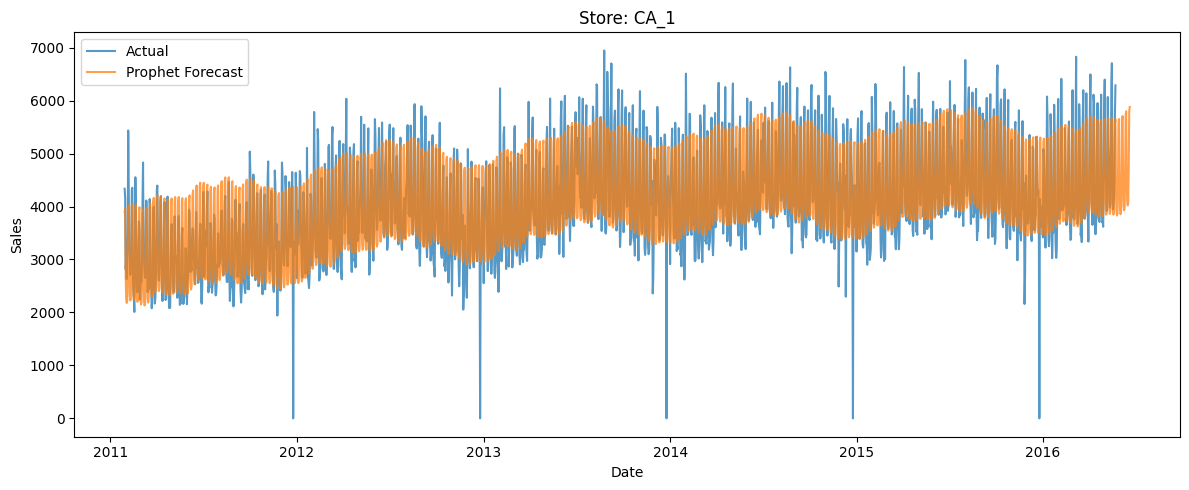

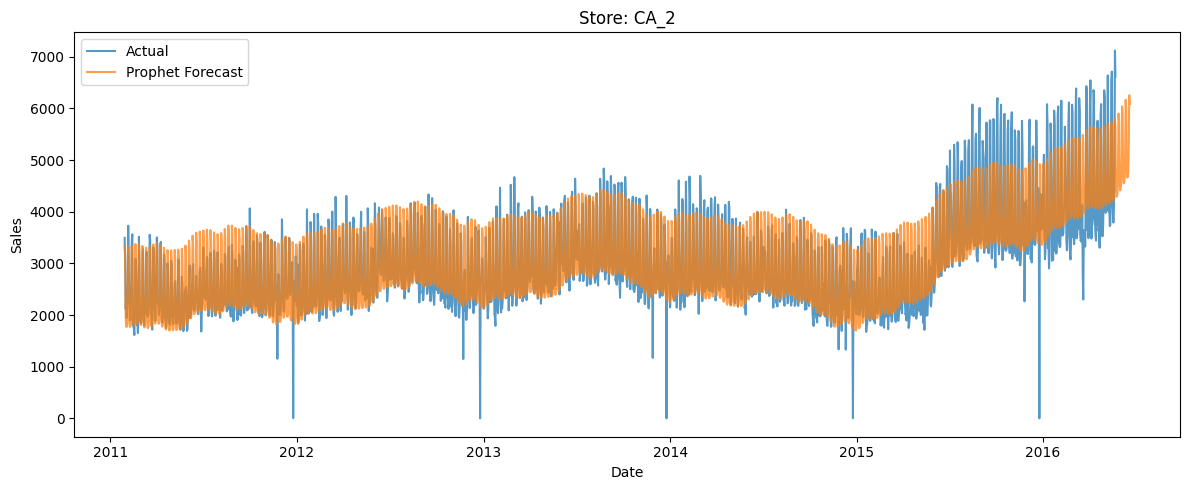

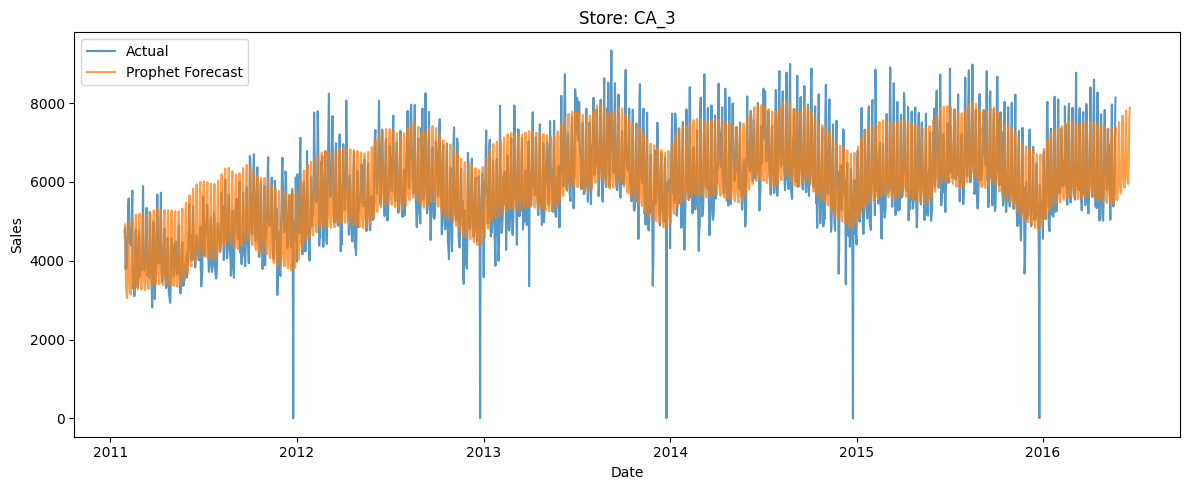

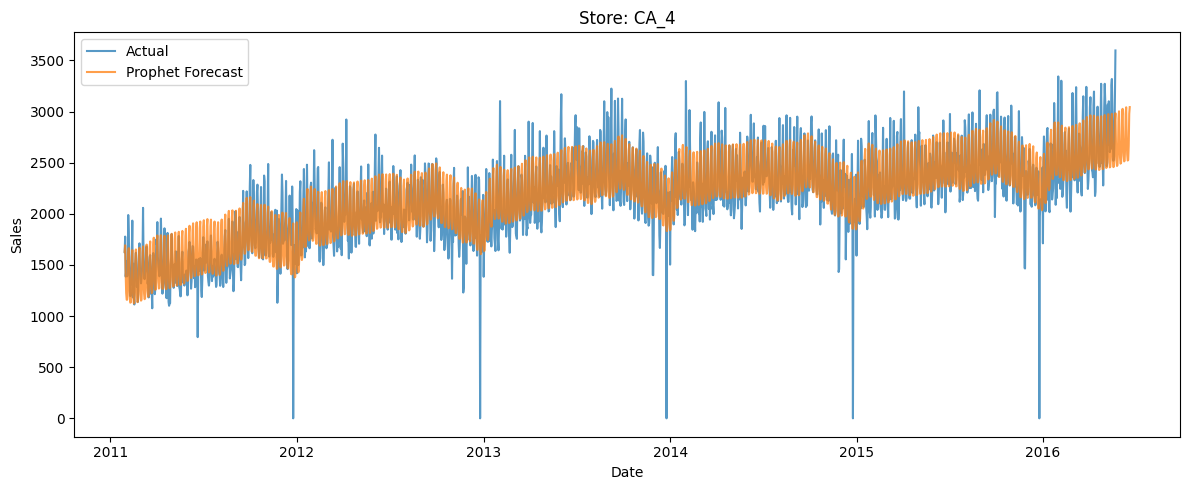

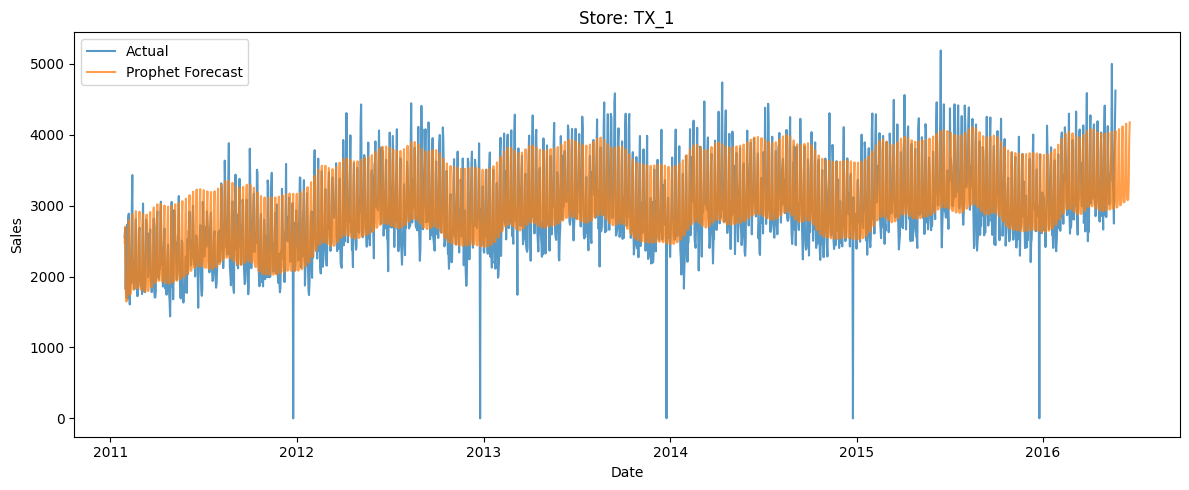

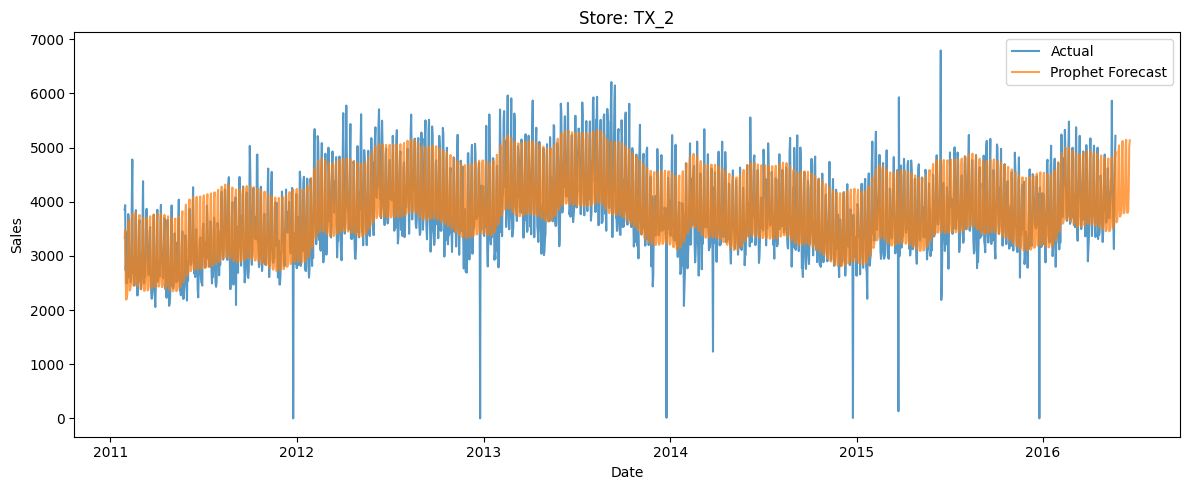

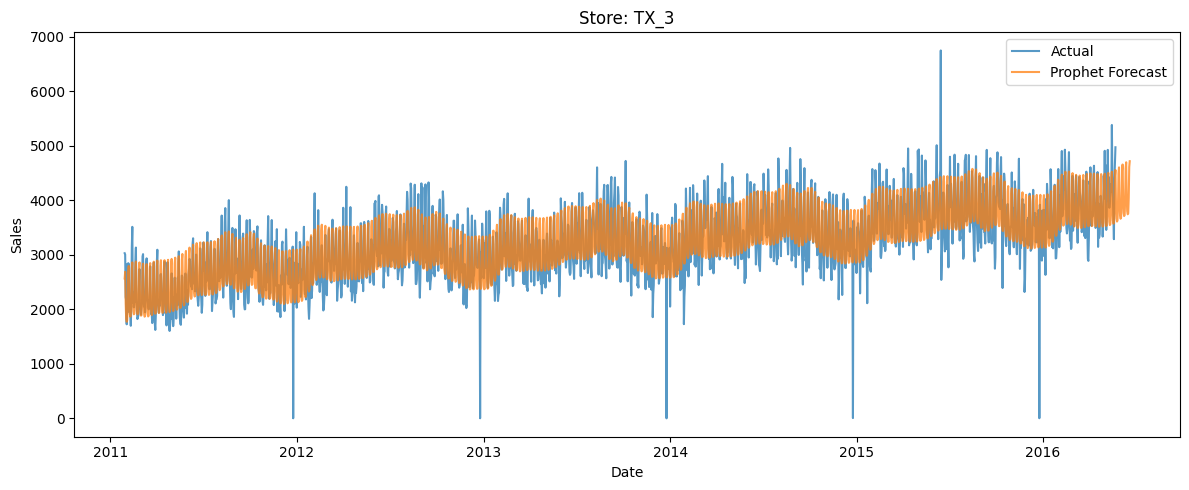

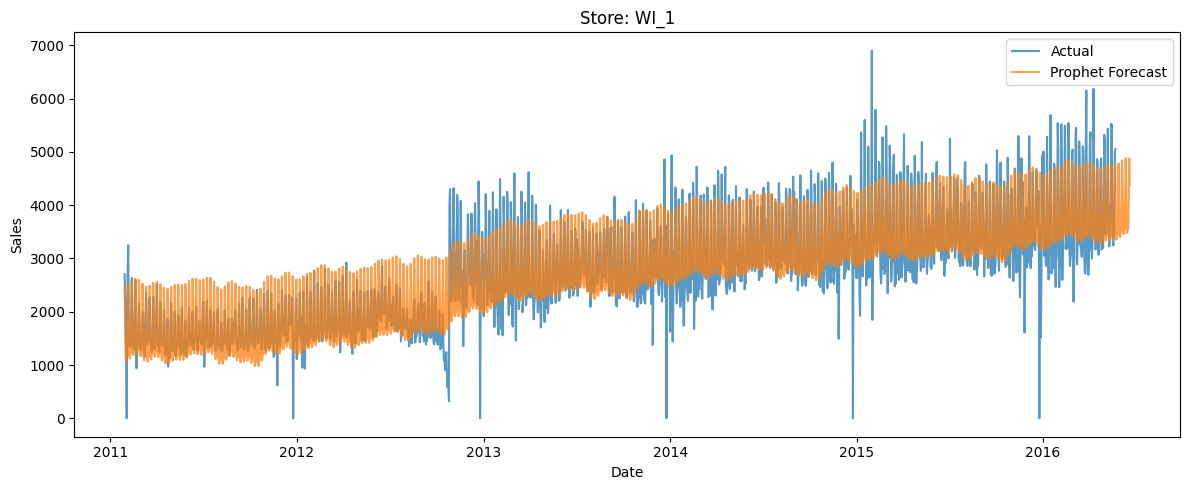

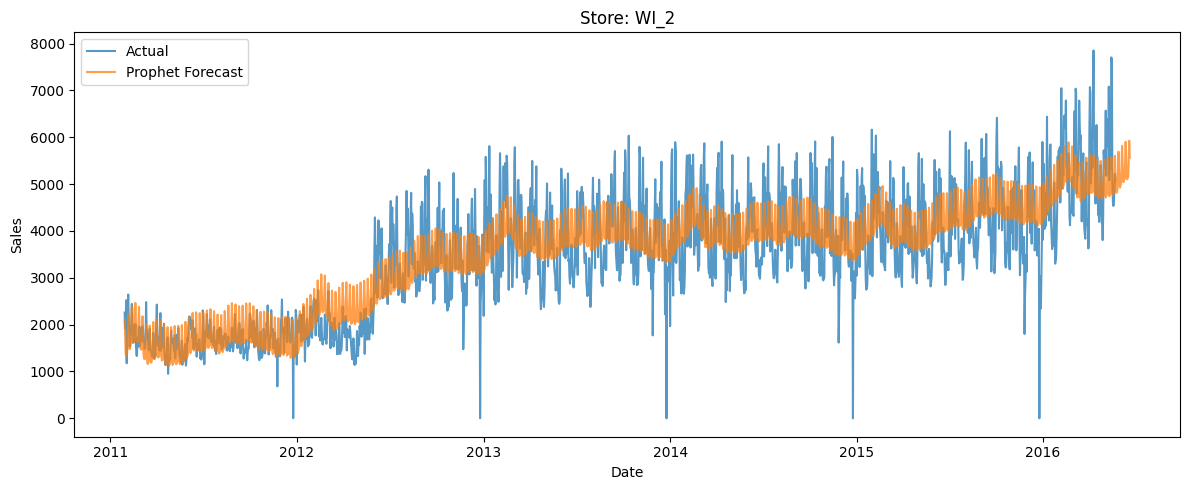

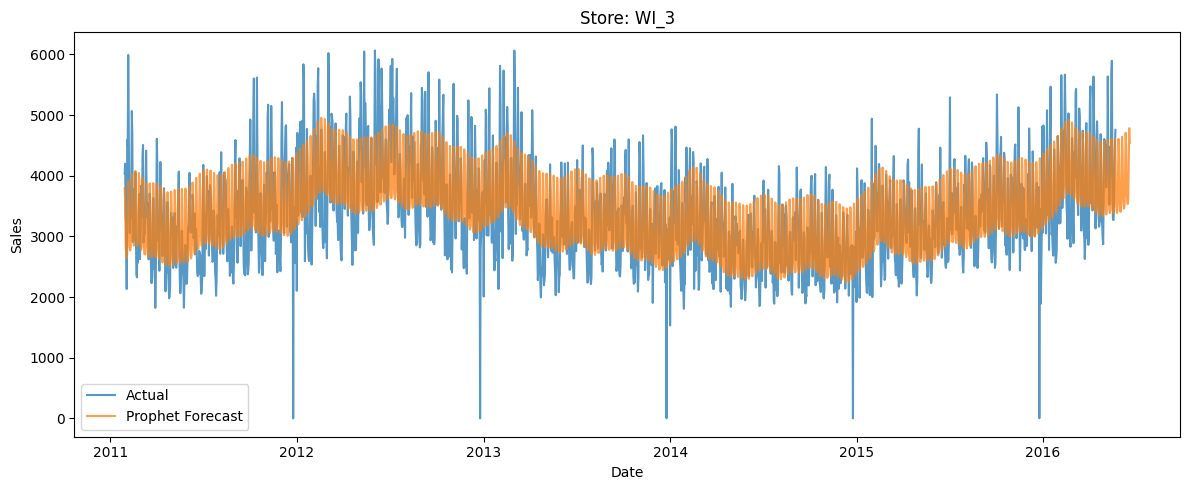

In [8]:
import matplotlib.pyplot as plt

# Reset index to merge easily
df_actual = cumulative_sales_time_series.reset_index().rename(columns={'d':'d', 'date':'ds'})
df_actual['ds'] = pd.to_datetime(df_actual['ds'])

df_forecast = df_cumulative_sales_forecasts.reset_index()

# Merge actuals and forecast on store_id and date
df_plot = pd.merge(
    df_actual[['store_id','ds','y']],
    df_forecast[['store_id','ds','yhat']],
    on=['store_id','ds'],
    how='outer'
)

stores = df_plot['store_id'].unique()

for store in stores:
    df_store = df_plot[df_plot['store_id'] == store]

    plt.figure(figsize=(12,5))
    plt.plot(df_store['ds'], df_store['y'], label='Actual', alpha=0.75)
    plt.plot(df_store['ds'], df_store['yhat'], label='Prophet Forecast', alpha=0.75)
    
    plt.title(f'Store: {store}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate a prices table per item for each store.

In [9]:
# fastest version compared to vectorized and parallel implementations (approx. 10 times faster then any of them) 
def generate_item_prices_per_day(initial_data):
    result = {}

    df_calendar = initial_data._df_calendar[['d','wm_yr_wk']]

    # Precompute item order per store ONCE
    df_items = (
        initial_data._df_sales_validation[['store_id','item_id']]
        .drop_duplicates()
    )

    item_order_per_store = {
        store: group['item_id'].tolist()
        for store, group in df_items.groupby('store_id')
    }

    # Pre-group prices (avoid repeated filtering)
    grouped_prices = initial_data._df_sell_prices.groupby('store_id')

    for store, df_store_prices in grouped_prices:

        pivot_prices = df_store_prices.pivot_table(
            index='wm_yr_wk',
            columns='item_id',
            values='sell_price',
            aggfunc='first'
        )

        # Restore original item order
        pivot_prices = pivot_prices.reindex(
            columns=item_order_per_store[store]
        )

        df = df_calendar.merge(
            pivot_prices.reset_index(),
            on='wm_yr_wk',
            how='left'
        ).set_index('d')

        result[store] = (
            df.drop(columns='wm_yr_wk', errors='ignore')
              .fillna(0)
        )

    return result

item_prices_per_day = generate_item_prices_per_day(initial_data)
print(item_prices_per_day)

{'CA_1':         HOBBIES_1_001  HOBBIES_1_002  HOBBIES_1_003  HOBBIES_1_004  \
d                                                                    
d_1              0.00           0.00           0.00           0.00   
d_2              0.00           0.00           0.00           0.00   
d_3              0.00           0.00           0.00           0.00   
d_4              0.00           0.00           0.00           0.00   
d_5              0.00           0.00           0.00           0.00   
...               ...            ...            ...            ...   
d_1965           8.38           3.97           2.97           4.64   
d_1966           8.38           3.97           2.97           4.64   
d_1967           8.38           3.97           2.97           4.64   
d_1968           8.38           3.97           2.97           4.64   
d_1969           8.38           3.97           2.97           4.64   

        HOBBIES_1_005  HOBBIES_1_006  HOBBIES_1_007  HOBBIES_1_008  \
d         

In [10]:
%timeit -n 1 -r 5 item_prices_per_day = generate_item_prices_per_day(initial_data)

3.05 s ± 24.2 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


# Calculate price indexes for each group of items (hobbies, household, foods), which are weighted averages of items prices in each group

In [11]:
def calculate_price_indexes_per_store(initial_data, item_prices_per_day):
    day_cols = [col for col in initial_data._df_sales_validation.columns if col.startswith('d_')]
    
    total_sales_per_item = (
        initial_data._df_sales_validation[day_cols]
        .sum(axis=1)
        .groupby(initial_data._df_sales_validation['item_id'])
        .sum()
    )

    item_cat_map = initial_data._df_sales_validation[['item_id', 'cat_id']].drop_duplicates()
    sales_with_cat = total_sales_per_item.reset_index(name='total_sales').merge(
        item_cat_map,
        on='item_id',
        how='left'
    )
    total_sales_per_category = (
        sales_with_cat
        .groupby('cat_id')['total_sales']
        .sum()
    )

    sales_with_cat['cat_total'] = sales_with_cat['cat_id'].map(total_sales_per_category)

    sales_with_cat['weight'] = (
        sales_with_cat['total_sales'] / sales_with_cat['cat_total']
    )
    weights_by_cat = {}

    for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
        df_cat = sales_with_cat[sales_with_cat['cat_id'] == cat]
        
        weights_by_cat[cat] = df_cat.set_index('item_id')['weight']

    features_per_store = {}

    for store in initial_data._store_ids:
        price_df = item_prices_per_day[store]
        
        features = pd.DataFrame(index=price_df.index)
        
        for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
            
            weights = weights_by_cat[cat]
            
            # Align columns
            common_items = price_df.columns.intersection(weights.index)
            
            features[f'{cat}_price_index'] = (
                price_df[common_items] @ weights.loc[common_items]
            )
        features_per_store[store]=features.copy()

    normalized_features_per_store = {}

    for key, df in features_per_store.items():
        normalized_features_per_store[key] = features_per_store[key] / features_per_store[key].max()
    
    return normalized_features_per_store

price_indexes_per_store = calculate_price_indexes_per_store(initial_data, item_prices_per_day)
print(price_indexes_per_store)

{'CA_1':         FOODS_price_index  HOBBIES_price_index  HOUSEHOLD_price_index
d                                                                    
d_1              0.582897             0.401408               0.428361
d_2              0.582897             0.401408               0.428361
d_3              0.582897             0.401408               0.428361
d_4              0.582897             0.401408               0.428361
d_5              0.582897             0.401408               0.428361
...                   ...                  ...                    ...
d_1965           0.999960             0.993309               0.998298
d_1966           0.999960             0.993309               0.998298
d_1967           0.999960             0.993309               0.998298
d_1968           1.000000             0.992629               0.998184
d_1969           1.000000             0.992629               0.998184

[1969 rows x 3 columns], 'CA_2':         FOODS_price_index  HOBBIES_price_index 

In [12]:
%timeit -n 1 -r 5 price_indexes_per_store = calculate_price_indexes_per_store(initial_data, item_prices_per_day)

372 ms ± 11.7 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


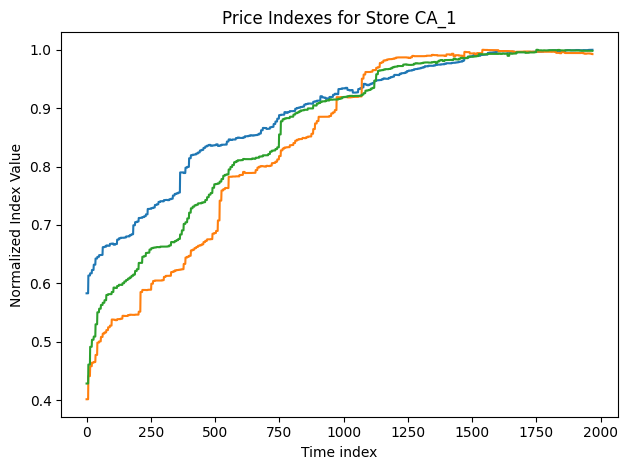

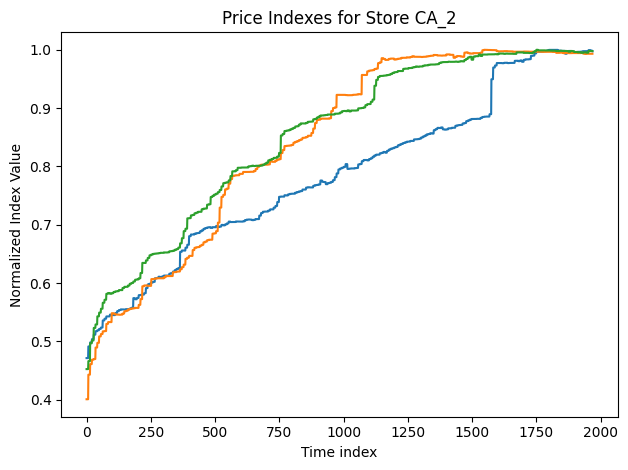

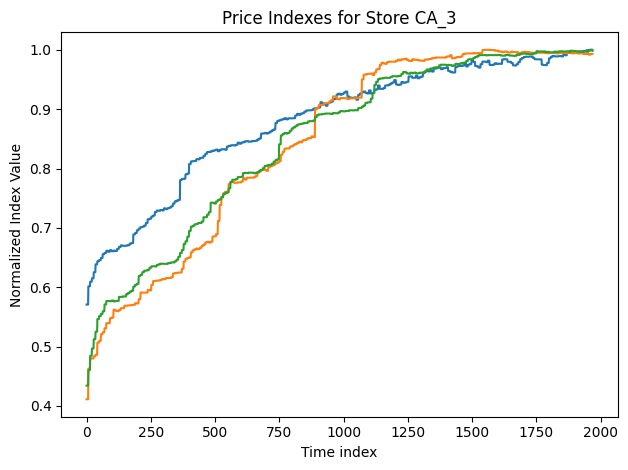

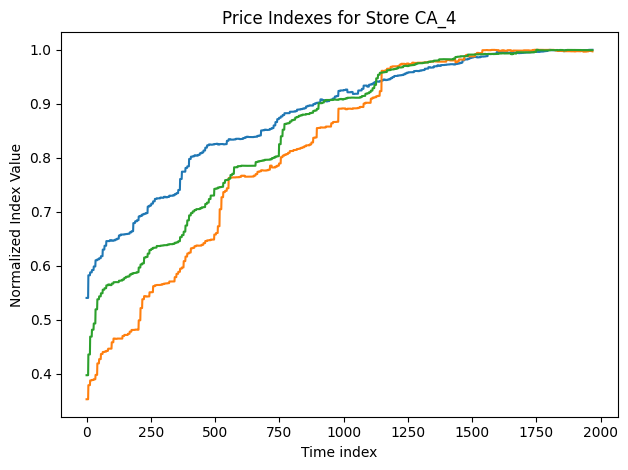

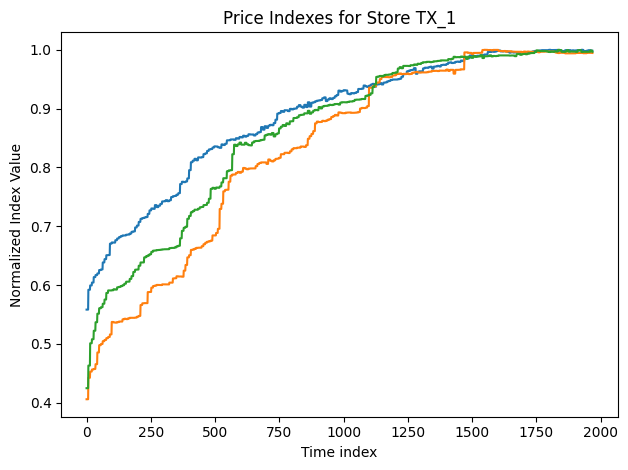

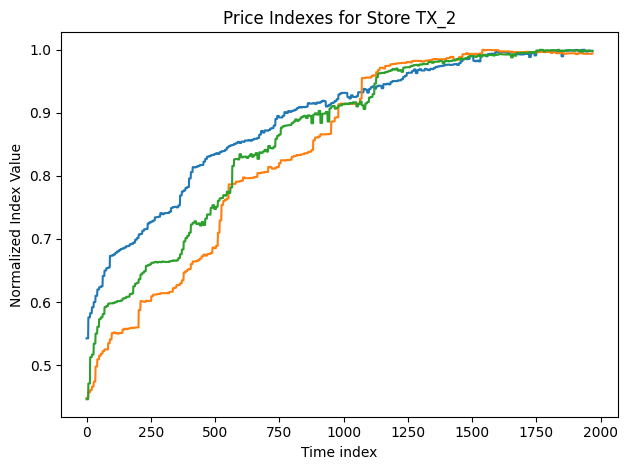

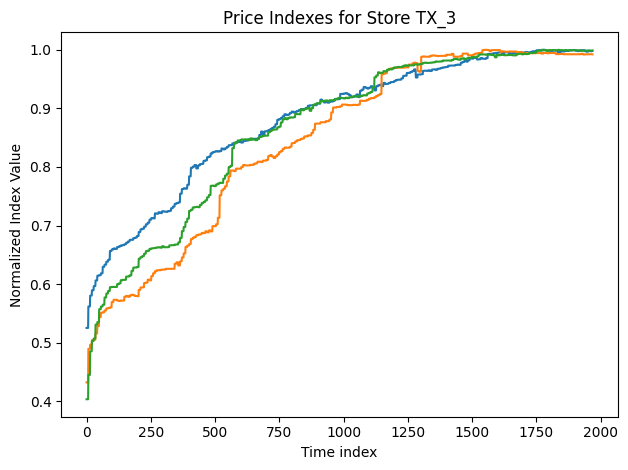

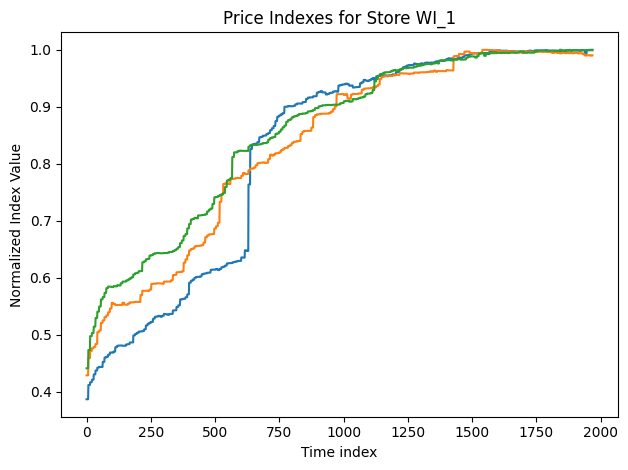

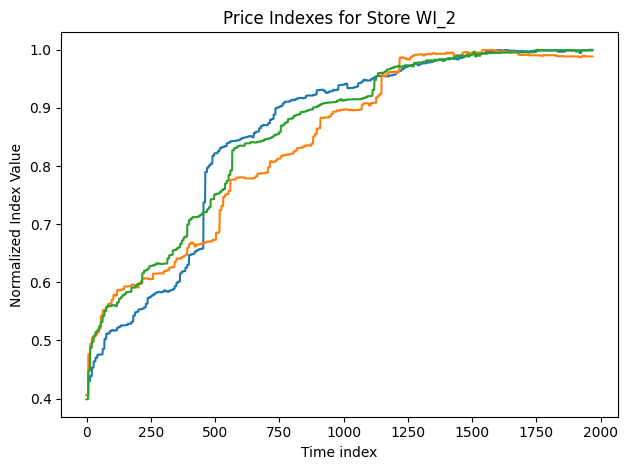

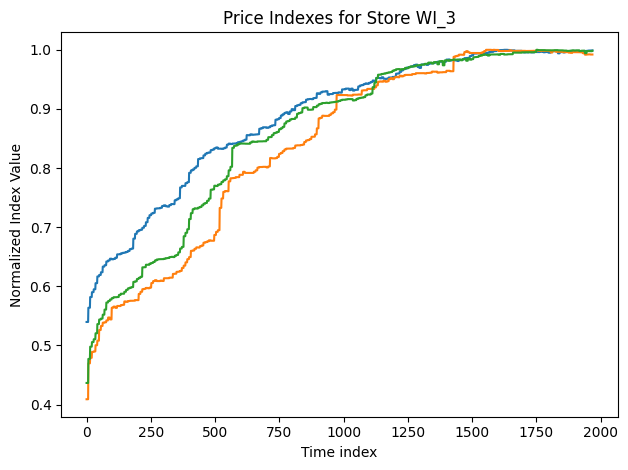

In [13]:
def plot_price_indexes(price_indexes_per_store, store_ids):
    for store in store_ids:
        fig, ax = plt.subplots()
        ax.plot(price_indexes_per_store[store].to_numpy())
        ax.set_xlabel("Time index")
        ax.set_ylabel("Normalized Index Value")
        ax.set_title(f"Price Indexes for Store {store}")

        fig.tight_layout()
        plt.show()

plot_price_indexes(price_indexes_per_store, initial_data._store_ids)

# Calculate features table for forecasting the cumulative sales behaviour

In [14]:
def calculate_initial_feature_table(
        prophet_forecasts,
        price_indexes,
        cumulative_sales,
        initial_data
):
    initial_features_table = {}

    # Prepare calendar
    calendar = initial_data._df_calendar.copy()
    calendar = calendar[
        [
            'date', 'd', 'wday', 'month',
            'event_name_1','event_type_1',
            'event_name_2','event_type_2',
            'snap_CA','snap_TX','snap_WI'
        ]
    ]
    calendar['date'] = pd.to_datetime(calendar['date'])

    # Convert global DataFrames from MultiIndex to normal columns
    df_forecasts_all = prophet_forecasts.reset_index()
    df_sales_all = cumulative_sales.reset_index()

    # Group by store_id for fast lookup
    forecast_groups = dict(tuple(df_forecasts_all.groupby('store_id')))
    sales_groups = dict(tuple(df_sales_all.groupby('store_id')))

    # price_indexes is already a dict keyed by store_id
    price_groups = price_indexes

    for store in initial_data._store_ids:

        # Extract per-store subsets
        df_forecast = forecast_groups[store][['ds', 'yhat']]
        df_sales = sales_groups[store][['d', 'y']]
        df_prices = price_groups[store]

        # Merge prices and sales on 'd'
        df = df_prices.merge(df_sales, on='d', how='left')

        # Merge with calendar to get 'date'
        df = df.merge(calendar, on='d', how='left')

        # Ensure datetime
        df['date'] = pd.to_datetime(df['date'])

        # Merge forecasts on date
        df = df.merge(
            df_forecast,
            left_on='date',
            right_on='ds',
            how='left'
        )

        df = df.drop(columns='ds')

        # Add metadata
        state = store.split('_')[0]
        df['state'] = state
        df['store_id'] = store

        snap_col = f'snap_{state}'
        df['snap'] = df[snap_col]

        # Reorder columns
        df = df[
            [
                'date','wday','month',
                'event_name_1','event_type_1',
                'event_name_2','event_type_2',
                'state','store_id','snap',
                'yhat',
                'FOODS_price_index','HOBBIES_price_index','HOUSEHOLD_price_index',
                'y'
            ]
        ]

        # Fill categorical missing values
        df[
            [
                'event_name_1','event_type_1',
                'event_name_2','event_type_2'
            ]
        ] = df[
            [
                'event_name_1','event_type_1',
                'event_name_2','event_type_2'
            ]
        ].fillna('None')

        initial_features_table[store] = df.copy()

    return initial_features_table
    
initial_feature_table = calculate_initial_feature_table(
    df_cumulative_sales_forecasts,
    price_indexes_per_store,
    cumulative_sales_time_series,
    initial_data
)
print(initial_feature_table)

{'CA_1':            date  wday  month  event_name_1 event_type_1  event_name_2  \
0    2011-01-29     1      1          None         None          None   
1    2011-01-30     2      1          None         None          None   
2    2011-01-31     3      1          None         None          None   
3    2011-02-01     4      2          None         None          None   
4    2011-02-02     5      2          None         None          None   
...         ...   ...    ...           ...          ...           ...   
1964 2016-06-15     5      6          None         None          None   
1965 2016-06-16     6      6          None         None          None   
1966 2016-06-17     7      6          None         None          None   
1967 2016-06-18     1      6          None         None          None   
1968 2016-06-19     2      6  NBAFinalsEnd     Sporting  Father's day   

     event_type_2 state store_id  snap         yhat  FOODS_price_index  \
0            None    CA     CA_1     0  

In [15]:
%timeit -n 1 -r 5 initial_feature_table = calculate_initial_feature_table(df_cumulative_sales_forecasts, price_indexes_per_store, cumulative_sales_time_series, initial_data)

87.3 ms ± 4.11 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


# Add lagged values of some initial features in order to add the information of time dependency.

In [16]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def calculate_laggs_for_feature_table(initial_features_table, future_days = 28):
    table_with_laggs = {}
    table_with_laggs_validation = {}
    keys = list(initial_features_table.keys())

    for store in keys:
        initial_table = initial_features_table[store]
        yhat_future_cols = {}
        yhat_past_cols = {}
        y_past_cols = {}
        y_future_cols = {}
        
        wday_future = {}
        month_future = {}
        event_name_1_future = {}
        event_type_1_future = {}
        event_name_2_future = {}
        event_type_2_future = {}
        
        for i in range(future_days):
            wday_future[f'wday_future_{i+1}'] = initial_table['wday'].shift(-(i + 1))
            month_future[f'month_future_{i+1}'] = initial_table['month'].shift(-(i + 1))
            event_name_1_future[f'event_name_1_future_{i+1}'] = initial_table['event_name_1'].shift(-(i + 1))
            event_type_1_future[f'event_type_1_future_{i+1}'] = initial_table['event_type_1'].shift(-(i + 1))
            event_name_2_future[f'event_name_2_future_{i+1}'] = initial_table['event_name_2'].shift(-(i + 1))
            event_type_2_future[f'event_type_2_future_{i+1}'] = initial_table['event_type_2'].shift(-(i + 1))
            yhat_future_cols[f'yhat_future_{i+1}'] = initial_table['yhat'].shift(-(i + 1))
            yhat_past_cols[f'yhat_past_-{i+1}'] = initial_table['yhat'].shift((i + 1))
            y_past_cols[f'y_past_-{i+1}'] = initial_table['y'].shift(i + 1)
            y_future_cols[f'y_future_{i+1}'] = initial_table['y'].shift(-(i + 1))
            
        
        # Concatenate all new columns at once
        future_and_past_shifts = pd.concat([
            pd.DataFrame(wday_future),
            pd.DataFrame(month_future),
            pd.DataFrame(event_name_1_future),
            pd.DataFrame(event_type_1_future),
            pd.DataFrame(yhat_future_cols),
            pd.DataFrame(yhat_past_cols),
            pd.DataFrame(y_past_cols),
            pd.DataFrame(y_future_cols)
        ], axis=1)
        
        df_store = pd.concat([initial_table, future_and_past_shifts], axis=1)
        df_store = df_store[:-28]
        table_with_laggs[store] = df_store.copy()
        table_with_laggs_validation[store] = df_store[:-29].copy()

        
    df_all = (
        pd.concat(table_with_laggs.values())
    )    

    df_all_validation = (
        pd.concat(table_with_laggs_validation.values())
        .drop(columns="date", errors="ignore")
        .dropna()
        .reset_index(drop=True)
    )  

    cat_cols = (['event_name_1','event_type_1','event_name_2','event_type_2','state','store_id']
    +[f'event_name_1_future_{i}' for i in np.arange(1,29)]
    +[f'event_type_1_future_{i}' for i in np.arange(1,29)]
    
    )
        
    for col in cat_cols:
        le = LabelEncoder()
        df_all[col] = le.fit_transform(df_all[col].astype(str))
        df_all_validation[col] = le.fit_transform(df_all_validation[col].astype(str))
        
    return df_all, df_all_validation

feature_table_with_laggs, feature_table_with_laggs_validation = calculate_laggs_for_feature_table(initial_feature_table)
print(feature_table_with_laggs)


           date  wday  month  event_name_1  event_type_1  event_name_2  \
0    2011-01-29     1      1            19             2             3   
1    2011-01-30     2      1            19             2             3   
2    2011-01-31     3      1            19             2             3   
3    2011-02-01     4      2            19             2             3   
4    2011-02-02     5      2            19             2             3   
...         ...   ...    ...           ...           ...           ...   
1936 2016-05-18     5      5            19             2             3   
1937 2016-05-19     6      5            19             2             3   
1938 2016-05-20     7      5            19             2             3   
1939 2016-05-21     1      5            19             2             3   
1940 2016-05-22     2      5            19             2             3   

      event_type_2  state  store_id  snap  ...  y_future_19  y_future_20  \
0                1      0         0

# Train the final forecasting models for cumulative sales predictions.

In [17]:
import joblib
import xgboost as xgb
from lightgbm import LGBMRegressor

def train_regressor(table_with_laggs_validation):

    label_cols = [f'y_future_{i}' for i in np.arange(1, 29)]

    # -------------------------
    # Train/test split
    # -------------------------
    features_train = table_with_laggs_validation.sample(frac=0.8, random_state=42)
    labels_train = features_train[label_cols]
    features_train = features_train.drop(columns=label_cols).reset_index(drop=True)
    labels_train = labels_train.reset_index(drop=True)

    features_test = table_with_laggs_validation.drop(features_train.index)
    labels_test = features_test[label_cols]
    features_test = features_test.drop(columns=label_cols).reset_index(drop=True)
    labels_test = labels_test.reset_index(drop=True)

    # -------------------------
    # Common setup
    # -------------------------
    future_horizons = labels_train.shape[1]

    # =========================================================
    # XGBoost
    # =========================================================
    xgb_models = []
    labels_train_pred_xgb = np.zeros_like(labels_train)
    labels_test_pred_xgb = np.zeros_like(labels_test)

    for i in range(future_horizons):
        model = xgb.XGBRegressor(
            n_estimators=110,
            max_depth=12,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )

        model.fit(features_train, labels_train.iloc[:, i])
        xgb_models.append(model)

        labels_train_pred_xgb[:, i] = model.predict(features_train)
        labels_test_pred_xgb[:, i] = model.predict(features_test)

        print(f"XGB {i} out of {future_horizons}")

    rmse_train_xgb = np.sqrt(np.mean((labels_train - labels_train_pred_xgb) ** 2, axis=0))
    rmse_test_xgb = np.sqrt(np.mean((labels_test - labels_test_pred_xgb) ** 2, axis=0))

    mean_rmse_train_xgb_pct = rmse_train_xgb.mean() / labels_train.values.mean() * 100
    mean_rmse_test_xgb_pct = rmse_test_xgb.mean() / labels_test.values.mean() * 100

    print(f"XGBoost Train RMSE%: {mean_rmse_train_xgb_pct:.2f}%")
    print(f"XGBoost Test RMSE%: {mean_rmse_test_xgb_pct:.2f}%")

    # Save XGB models
    os.makedirs("xgb_models_28d", exist_ok=True)
    for i, model in enumerate(xgb_models):
        filepath = os.path.join("xgb_models_28d", f"xgb_model_h{i}.pkl")
        joblib.dump(model, filepath)
    
    # =========================================================
    # LightGBM
    # =========================================================
    lgbm_models = []
    labels_train_pred_lgbm = np.zeros_like(labels_train)
    labels_test_pred_lgbm = np.zeros_like(labels_test)

    for i in range(future_horizons):
        model = LGBMRegressor(
            n_estimators=700,
            learning_rate=0.1,
            max_depth=-1,
            num_leaves=128,
            subsample=0.8,
            colsample_bytree=0.5,
            random_state=42,
            n_jobs=-1
        )

        model.fit(features_train, labels_train.iloc[:, i])
        lgbm_models.append(model)

        labels_train_pred_lgbm[:, i] = model.predict(features_train)
        labels_test_pred_lgbm[:, i] = model.predict(features_test)

        print(f"LGBM {i} out of {future_horizons}")

    rmse_train_lgbm = np.sqrt(np.mean((labels_train - labels_train_pred_lgbm) ** 2, axis=0))
    rmse_test_lgbm = np.sqrt(np.mean((labels_test - labels_test_pred_lgbm) ** 2, axis=0))

    mean_rmse_train_lgbm_pct = rmse_train_lgbm.mean() / labels_train.values.mean() * 100
    mean_rmse_test_lgbm_pct = rmse_test_lgbm.mean() / labels_test.values.mean() * 100

    print(f"LightGBM Train RMSE%: {mean_rmse_train_lgbm_pct:.2f}%")
    print(f"LightGBM Test RMSE%: {mean_rmse_test_lgbm_pct:.2f}%")

    # Save LGBM models
    os.makedirs("lgbm_models_28d", exist_ok=True)
    for i, model in enumerate(lgbm_models):
        filepath = os.path.join("lgbm_models_28d", f"lgbm_model_h{i}.pkl")
        joblib.dump(model, filepath)

    return {"xgb_models": xgb_models, "lgbm_models": lgbm_models}

cumulative_sales_forecast_models = train_regressor(feature_table_with_laggs_validation)

XGB 0 out of 28
XGB 1 out of 28
XGB 2 out of 28
XGB 3 out of 28
XGB 4 out of 28
XGB 5 out of 28
XGB 6 out of 28
XGB 7 out of 28
XGB 8 out of 28
XGB 9 out of 28
XGB 10 out of 28
XGB 11 out of 28
XGB 12 out of 28
XGB 13 out of 28
XGB 14 out of 28
XGB 15 out of 28
XGB 16 out of 28
XGB 17 out of 28
XGB 18 out of 28
XGB 19 out of 28
XGB 20 out of 28
XGB 21 out of 28
XGB 22 out of 28
XGB 23 out of 28
XGB 24 out of 28
XGB 25 out of 28
XGB 26 out of 28
XGB 27 out of 28
XGBoost Train RMSE%: 1.64%
XGBoost Test RMSE%: 5.78%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24369
[LightGBM] [Info] Number of data points in the train set: 15072, number of used features: 210
[LightGBM] [Info] Start training from score 3448.809713
LGBM 0 out of 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032072 seconds.
You can set `